# Online Retail - Exploratry data analysis
## Import necessary libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import calendar
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


## Read input file

In [4]:
df  = pd.read_excel("Online Retail.xlsx")

## Some data quality check before data filtering

In [5]:
#=== print few lines
df.head()
#=== print the number of rows and columns in dataframe
df.shape
#=== print column data types information
df.info()
#=== print basic statistics of numeric columns
df.describe()
#=== check duplicate rows
df.duplicated().value_counts()
print("There are ",df.duplicated().value_counts().reset_index().iloc[1,1]," duplicate values")
#=== check missing data after filtering
df.isna().sum()
print("There are lot of missing data in Description and CustomerID")
#=== check if date format is right
df[pd.to_datetime(df['InvoiceDate'], errors='coerce').notna()].shape
print("No missing or invalid format in InvoiceDate column")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


(541909, 8)

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


False    536641
True       5268
Name: count, dtype: int64

There are  5268  duplicate values


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

There are lot of missing data in Description and CustomerID


(541909, 8)

No missing or invalid format in InvoiceDate column


In [4]:
def clean_data(df):
    df_copy = df.copy()
    #=== remove duplicate rows
    df_copy = df_copy.drop_duplicates()
    #=== remove missing customer id rows, this also remove missing data from Description column
    df_clean = df_copy[df_copy['CustomerID'].notna()]
    #=== seperate out cancellations using InvoiceNo
    is_cancel = df_clean['InvoiceNo'].astype(str).str.startswith('C')
    df_clean = df_clean[~is_cancel]
    #=== replace negative values with 0 in numeric columns (not necessary as negative values are removed in above step)
    #numeric_cols = df.select_dtypes(include='number').columns
    #df_clean[numeric_cols] = df_clean[numeric_cols].clip(lower=0)
    #=== extract year and month information
    df_clean['Year'] = pd.to_datetime(df_clean['InvoiceDate']).dt.year
    df_clean['Month'] = pd.to_datetime(df_clean['InvoiceDate']).dt.month
    df_clean['DayofWeek'] = pd.to_datetime(df_clean['InvoiceDate']).dt.day_name()
    #=== calculate revenue
    df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
    #=== remove white spaces in Description column
    df_clean['Description'] = df_clean['Description'].astype('string').str.strip()
    #=== change CustomerID data type
    df_clean['CustomerID'] = df_clean['CustomerID'].astype('int64').astype('string')
    return df_clean    

In [ ]:
def print_info(df_clean):
    print("Best selling product",df_clean.Description.value_counts().idxmax())
    print("Most valuable customer ID",df_clean.CustomerID.value_counts().idxmax())
    print("Busiest month of the year by number of products sold is ",calendar.month_name[df_clean.groupby('Month')['Quantity'].sum().sort_values(ascending=False).idxmax()])
    print("Busiest day of the week by number of products sold is ",df_clean.groupby('DayofWeek')['Quantity'].sum().sort_values(ascending=False).idxmax())
    print("Top selling country is",df_clean.groupby('Country')['Quantity'].sum().sort_values(ascending=False).idxmax())
    print("Busiest month of the year by Revenue is ",calendar.month_name[df_clean.groupby('Month')['Revenue'].sum().sort_values(ascending=False).idxmax()])
    print("Busiest day of the week by Revenue is ",df_clean.groupby('DayofWeek')['Revenue'].sum().sort_values(ascending=False).idxmax())
    print("Top Revenue making country is",df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).idxmax())

## QC and print important observations of data

In [5]:
df_clean = clean_data(df)
print("Before clearning, number of rows", df.shape[0])
print("After clearning, number of rows", df_clean.shape[0])
print_info(df_clean)


Before clearning, number of rows 541909
After clearning, number of rows 392732
Best selling product WHITE HANGING HEART T-LIGHT HOLDER
Most valuable customer ID 17841
Busiest month of the year by number of products sold is  November
Busiest day of the week by number of products sold is  Thursday
Top selling country is United Kingdom
Busiest month of the year by Revenue is  November
Busiest day of the week by Revenue is  Thursday
Top Revenue making country is United Kingdom


## Is the Quantity and UnitPrice column normally distributed

In [ ]:
#=== normality test on Quantity column
stat, pvalue = stats.shapiro(df['Quantity'])
print("Quantity column is not normally distributed", pvalue)
stat, pvalue = stats.shapiro(df['UnitPrice'])
print("UnitPrice column is not normally distributed", pvalue)

plt.figure()
sns.boxplot(np.log10(df_clean.Quantity+1))
plt.title("Quanity distribution")
plt.show()

plt.figure()
sns.boxplot(np.log10(df_clean.UnitPrice+1))
plt.title("Quanity distribution")
plt.show()

## Plot top 10 Products and Countries

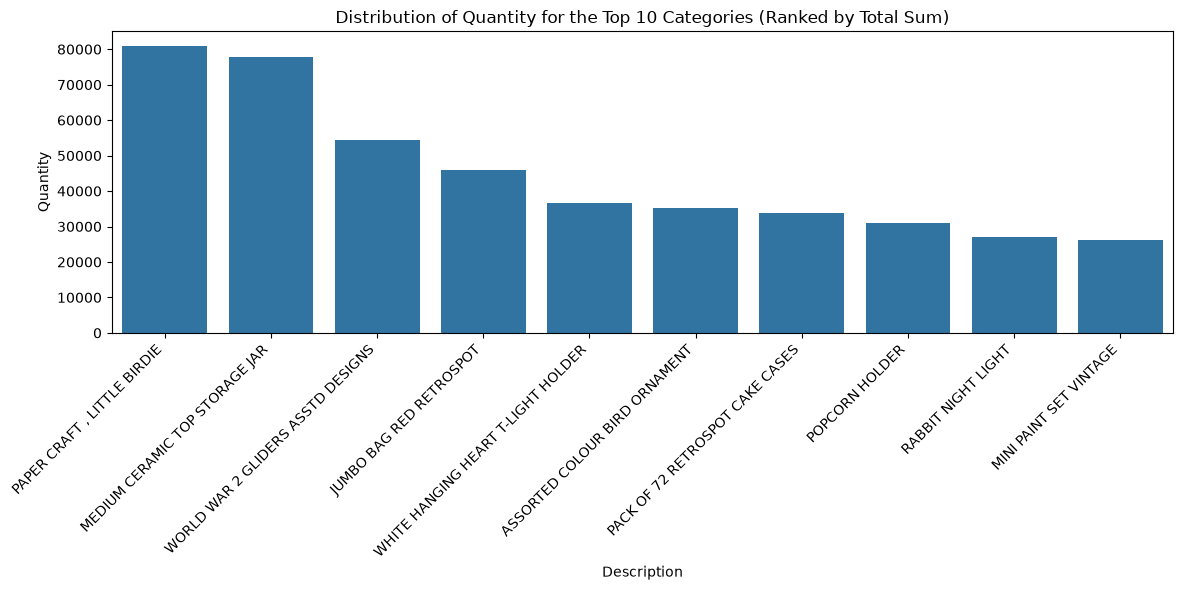

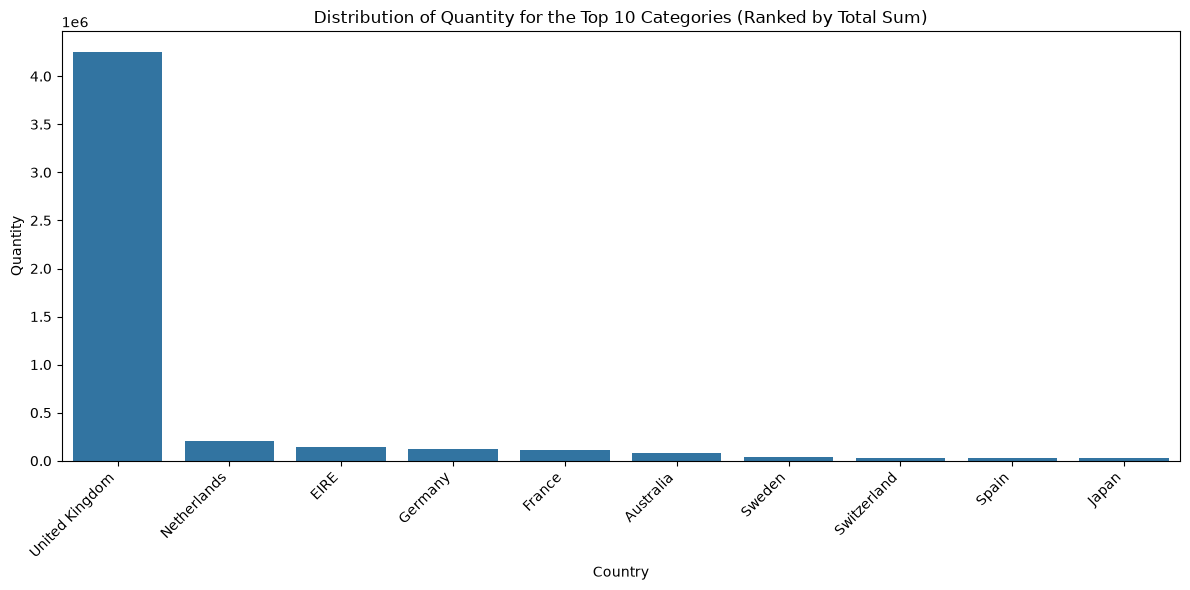

In [14]:


def plot_top_products(df_copy,xvariable,yvariable):
    #=== find out top 10 products sold by Quantity
    
    top_10_categories = (
        df_copy.groupby(xvariable)[yvariable]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    #=== filter the top categories
    df_filtered = df_copy[df_copy[xvariable].isin(top_10_categories)]
    
    #=== plot the top categories
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df_filtered, 
        x=xvariable, 
        y=yvariable,
        order = top_10_categories,
        estimator='sum',
        errorbar=None
    )
    plt.title('Distribution of Quantity for the Top 10 Categories (Ranked by Total Sum)')
    plt.xticks(rotation=45,ha='right')
    plt.tight_layout()
    plt.show()

df_copy = df_clean.copy()
#=== display top products by number sold and revenue
plot_top_products(df_copy,'Description','Quantity')

#=== display top countries by number sold and revenue
plot_top_products(df_copy,'Country','Quantity')



## Plot relation between Month and Number of Products sold

<Figure size 800x500 with 0 Axes>

<Axes: xlabel='Month_labels', ylabel='Quantity'>

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'November'),
  Text(1, 0, 'December'),
  Text(2, 0, 'October'),
  Text(3, 0, 'September'),
  Text(4, 0, 'August'),
  Text(5, 0, 'May'),
  Text(6, 0, 'July'),
  Text(7, 0, 'June'),
  Text(8, 0, 'January'),
  Text(9, 0, 'March'),
  Text(10, 0, 'April'),
  Text(11, 0, 'February')])

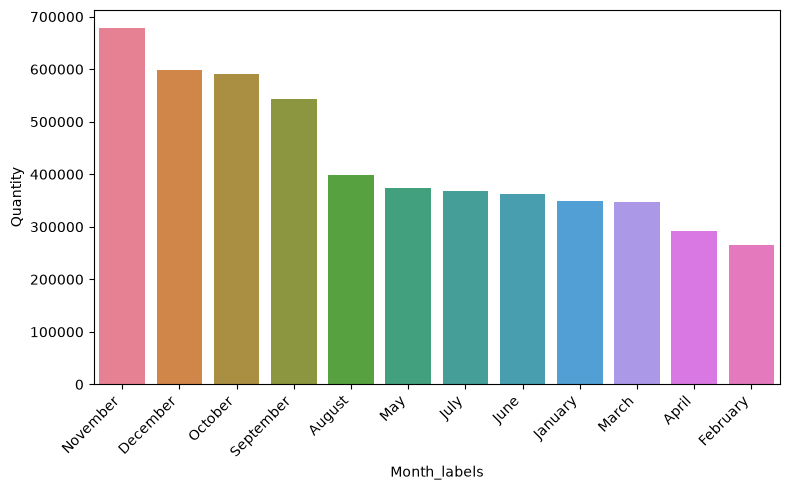

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='Month', ylabel='Quantity'>

Text(0.5, 1.0, 'Strong correlation between Month and number of products sold, 0.0001244832983888931')

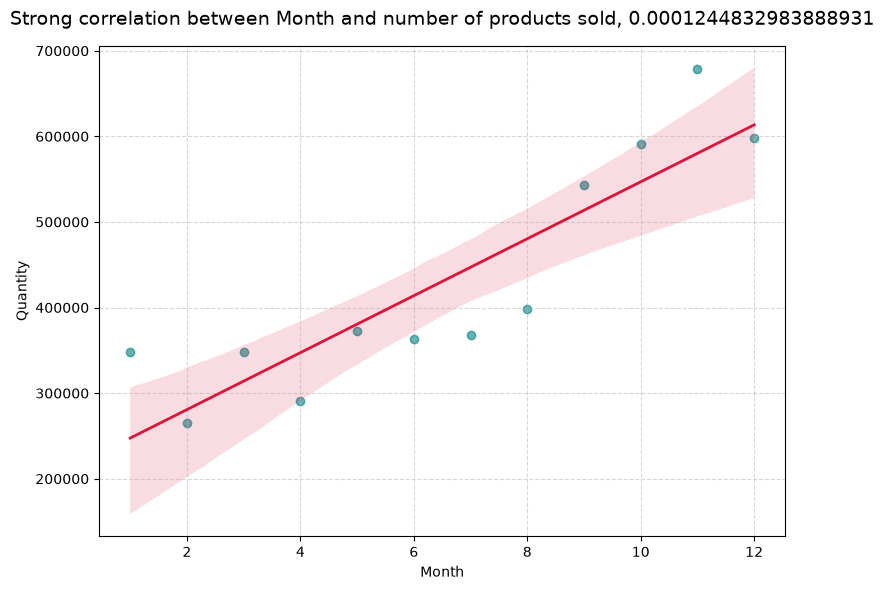

In [15]:
#=== plot the busiest months chart

df_copy = df_clean.copy()

temp = pd.DataFrame(df_copy.groupby('Month')['Quantity'].sum().sort_values(ascending=False))
temp['Month'] = temp.index
temp['Month_labels'] = [calendar.month_name[m] for m in temp.Month]


plt.figure(figsize=(8, 5))
sns.barplot(data=temp, x='Month_labels', y='Quantity', hue='Month_labels', legend=False, order = list(temp.Month_labels))
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()


#=== correlation between month and products sold

corr_coeff, p_value = stats.pearsonr(temp['Month'], temp['Quantity'])

plt.figure(figsize=(8, 6))

# regplot draws a scatterplot AND a best-fit trend line
sns.regplot(
    data=temp, 
    x='Month', 
    y='Quantity', 
    scatter_kws={'alpha':0.6, 'color':'teal'}, # Style the dots
    line_kws={'color':'crimson', 'linewidth': 2} # Style the trend line
)

# Display the correlation coefficient directly on the chart title
plt.title(f'Strong correlation between Month and number of products sold, {p_value}', fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Print most valuable customer for each Country

In [16]:
df_copy = df_clean.copy()

top_customers = (
    df_copy.groupby([ 'CustomerID','Country'])['Quantity']   # or your quantity/units column
        .sum()
        .reset_index()
        .sort_values(['Country', 'Quantity'], ascending=[True, False])
        .drop_duplicates(subset='Country', keep='first')
        .reset_index(drop=True)
        .sort_values(['Quantity'], ascending = False)
)

#=== top customer in every country by number of products sold
top_customers

,CustomerID,Country,Quantity
23,14646,Netherlands,197491
35,16446,United Kingdom,80997
10,14911,EIRE,80490
0,12415,Australia,77670
31,17404,Sweden,32748
19,12753,Japan,11421
24,12433,Norway,11071
13,12678,France,10923
14,12471,Germany,8200
30,12540,Spain,6685
